# Garmin Race Prediction Analysis

### Introduction
Newer Garmin hardware has been equipped with a race prediction feature which computes race predictions for different distances (5k, 10k, Half Marathon, and Marathon). I have often found myself surprised by how often these predictions accurately represent my current fitness, and how some other times they seem to be far off.

After having cleaned and engineered numerous datasets, I will proceed by doing a more in depth analysis of my Garmin's race prediction feature. I will specifically aim to answer the following questions:

- How did Garmin's race predictions evolve as my training became more consistent and marathon-focused?
- When did Garmin race predictions become more stable?
- Did marathon predictions overshoot actual fitness?

In addition I will be exploring other related trends in Garmin race prediction against observed performance.

### Data & Methodology
This notebook will make use of previously cleaned and engineered datasets derived from my personal Garmin Connect export files. Specifically, I will be working with Garmin race predictions for the 5K, 10K, Half Marathon and Marathon, focusing on the latter since it is my main event. For more details on these datasets, the cleaning performed and additional engineering refer to notebooks 01-07. During the development of this analysis, I manually created an events table to track key training block starts and race dates. This contextual layer allows Garmin prediction trends to be evaluated against real training and racing milestones.

### Imports

In [1]:
# Necessary imports for exploration
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tabulate import tabulate
from pathlib import Path

In [2]:
DATA_DIR = Path("../data_processed")
DATA_RAW_DIR = Path("../data_raw")

### Helper Functions

In [3]:
########################
### Helper functions ###
########################

# Data saving helper functions
def to_parquet(df, path):
    """Save a DataFrame to a Parquet file."""
    df.to_parquet(path, index=False)

# Plotting helper functions
def plot_line(df, x_col, y_col, title=None):
    """Plot a line graph of two columns from a DataFrame."""
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=df, x=x_col, y=y_col)
    plt.title(title)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
def plot_line_with_events(events_table, df, prediction, title=None):
    """Plot a line graph with vertical lines for events."""

    # Select races
    race_events = events_table[
        events_table["event_type"] == "race"
    ]

    # Select training block starts ()
    block_events = events_table[
        events_table["event_type"] == "training_block_start"
        ]

    plt.figure(figsize=(12, 6))

    # Prediction curve
    sns.lineplot(
        data=df,
        x='date',
        y=prediction,
        linewidth=2
    )

    # Race markers
    for _, row in race_events.iterrows():
        plt.axvline(
            row["date"],
            color='red',
            linestyle='--',
            alpha=0.6
        )

        plt.text(
            row["date"],
            df[prediction].max(),
            row["label"],
            rotation=90,
            fontsize=8,
            verticalalignment='top'
        )

    # Training block starts
    for _, row in block_events.iterrows():
        plt.axvline(
            row["date"],
            color='green',
            linestyle=':',
            alpha=0.5
        )

    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Time (minutes)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Data frame helper functions
def merge_dataframes_asof(left_df, right_df, left_on, right_on, direction='backward'):
    """Merge two DataFrames using an asof merge."""
    return pd.merge_asof(
        left_df.sort_values(left_on),
        right_df.sort_values(right_on),
        left_on=left_on,
        right_on=right_on,
        direction=direction
    )

# Getter function for relevant prediction
def get_relevant_prediction(row):
    """Get the relevant prediction based on the race type."""
    prediction_map = {
        "5k": "5K_pred",
        "10k": "10K_pred",
        "half": "Half_pred",
        "marathon": "Marathon_pred"
    }
    pred_col = prediction_map.get(row["race_type"])
    if pred_col:
        return row[pred_col]
    return None

### Garmin Race Predictions Over Time

I begin by observing how the Garmin race predictions have evolved since this data began to be collected. Furthermore, I compare the evolution of these predictions with specific training block dates and racing dates with the goal of observing any patterns or specific behavior.

The following visualizations show how Garmin’s race predictions evolved over time across multiple race distances. These predictions are generated internally by Garmin using physiological and training-derived metrics such as VO2 max estimation, training load, and recent performance patterns.

The purpose of this section is to establish a high-level view of how predicted race fitness evolved throughout different phases of training and racing.

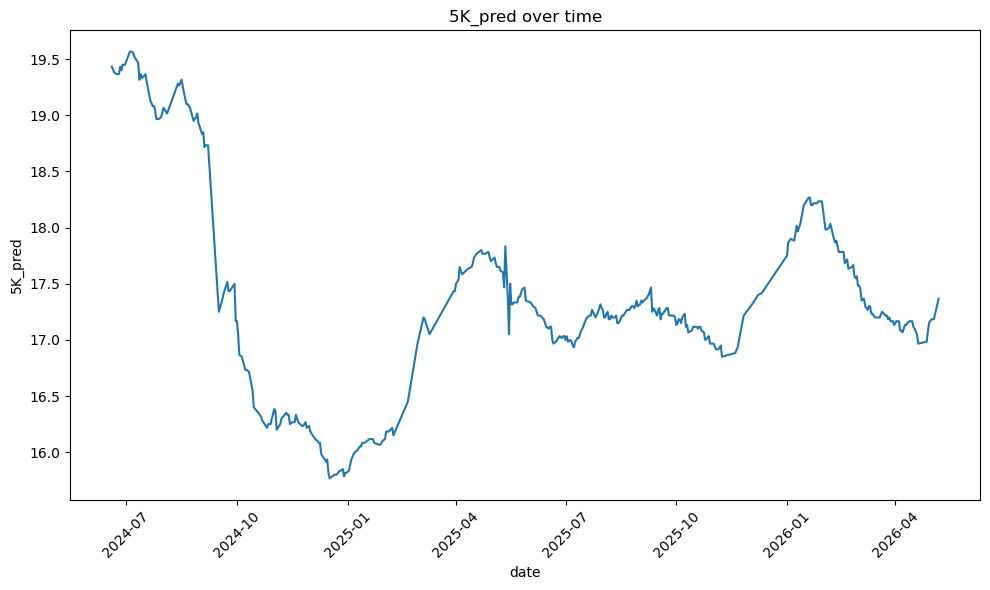

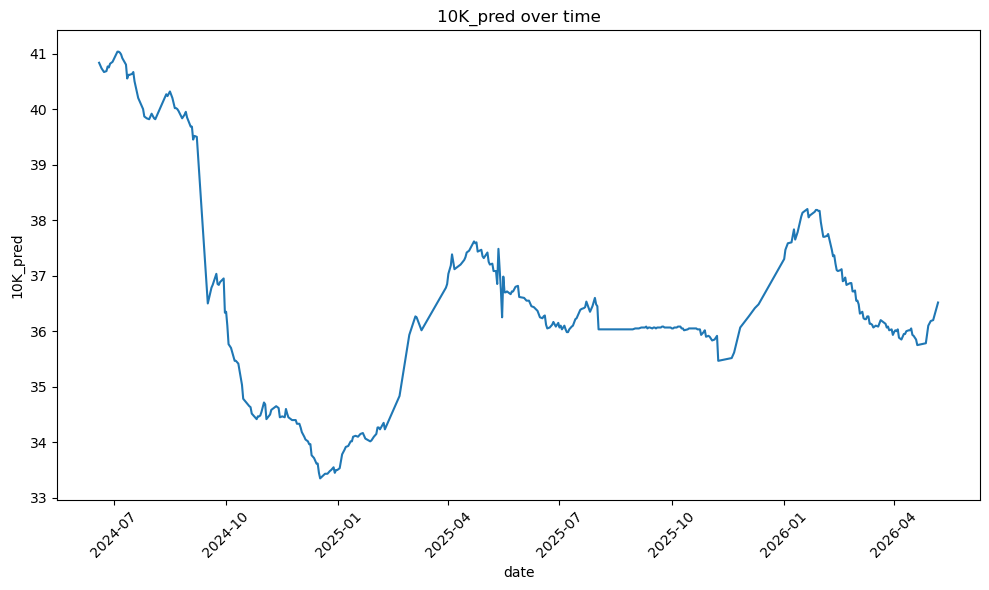

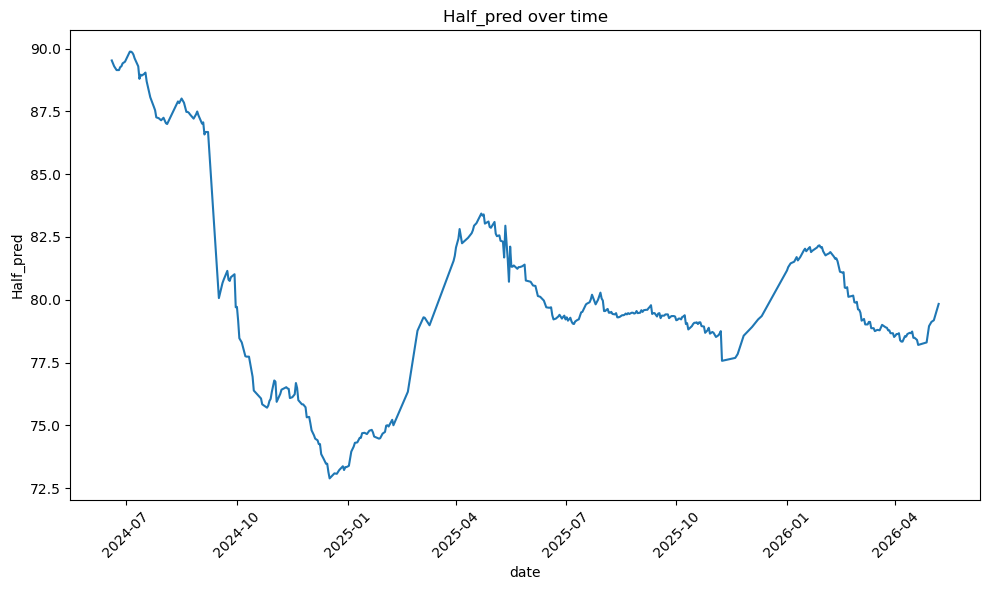

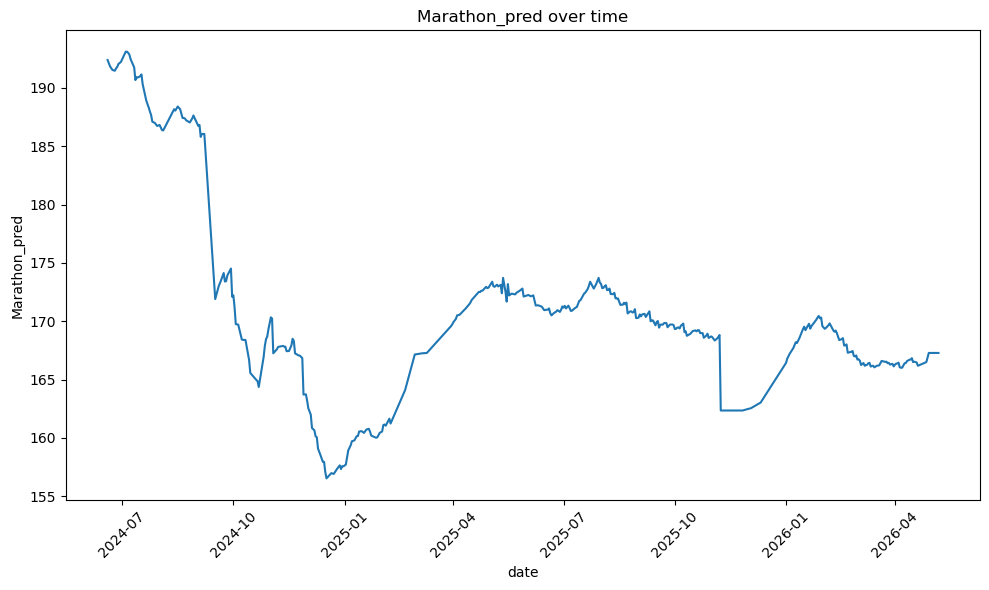

In [4]:
# Looad parquet file into a pandas DataFrame
daily_master_table = pd.read_parquet(DATA_DIR / 'daily_master_v1.parquet')

# Replace a bug value of 511 in the 'hrv_weekly_avg_last' column with NaN
daily_master_table["hrv_weekly_avg_clean"] = (
    daily_master_table["hrv_weekly_avg_last"]
    .replace(511, np.nan)
)

# Converting prediction times to seconds in order to be used in analysis
predictions_type = ['5K_pred', '10K_pred', 'Half_pred', 'Marathon_pred']

for prediction in predictions_type:
    daily_master_table[prediction] = pd.to_timedelta(daily_master_table[prediction]) # minutes
    daily_master_table[prediction] = (
    pd.to_timedelta(daily_master_table[prediction])
    .dt.total_seconds() / 60
)
    
# Plot garmin race predictions over time
for prediction in predictions_type: 
    plot_line(daily_master_table, 'date', prediction, title=f'{prediction} over time')

Above we observe plots of Garmin prediction times over time for the four main events. I observe a very fast decline in predicted time during 2024, followed by an aggresive increse from January 2025 to around May 2025. After this it appears as though predicted time stabilizes, resulting in a very interesting pattern of humps. These humps may represent different cycles in my training (off-cycles, training, peaks etc,.). Interestingly these hump structures appear to line up between all four distances, appearing to be more aggresive for 5k and 10k predictions. I am captivated by the intial aggresive dip in prediction time. 

### Overlaying Race Events

To contextualize Garmin’s predictions, major races and training blocks were manually annotated and overlaid onto the prediction timelines. This allows predicted performance trends to be compared against actual race outcomes and important training milestones.


/var/folders/5p/042l2mfn5lg_ltr5w11xxs9h0000gn/T/ipykernel_14101/3054608240.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  events_table['date'] = pd.to_datetime(events_table['date'])


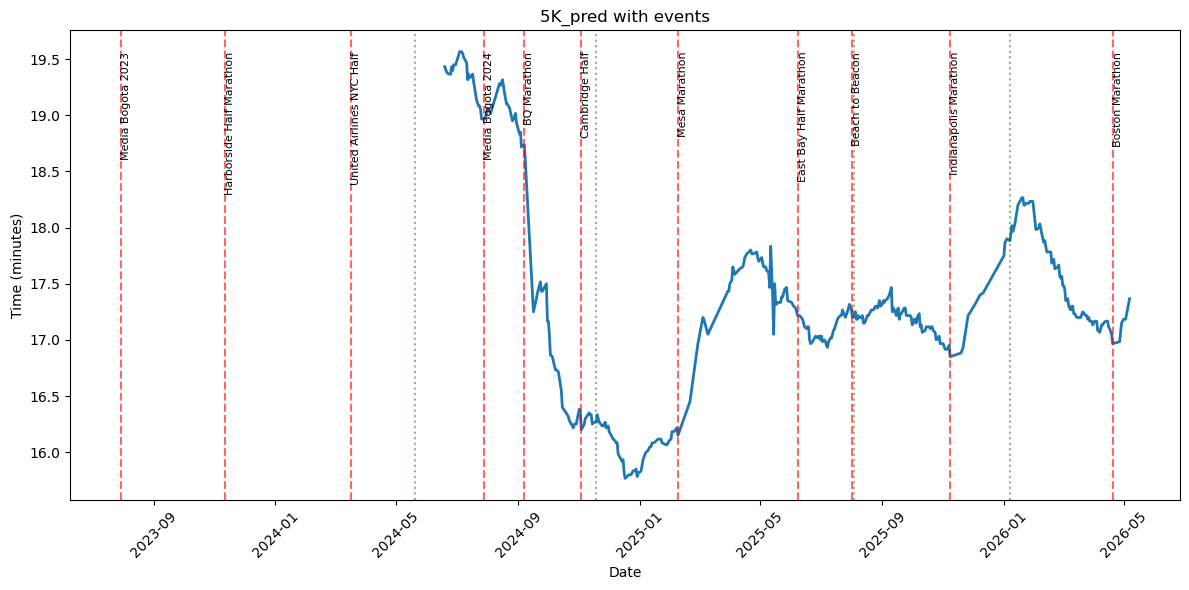

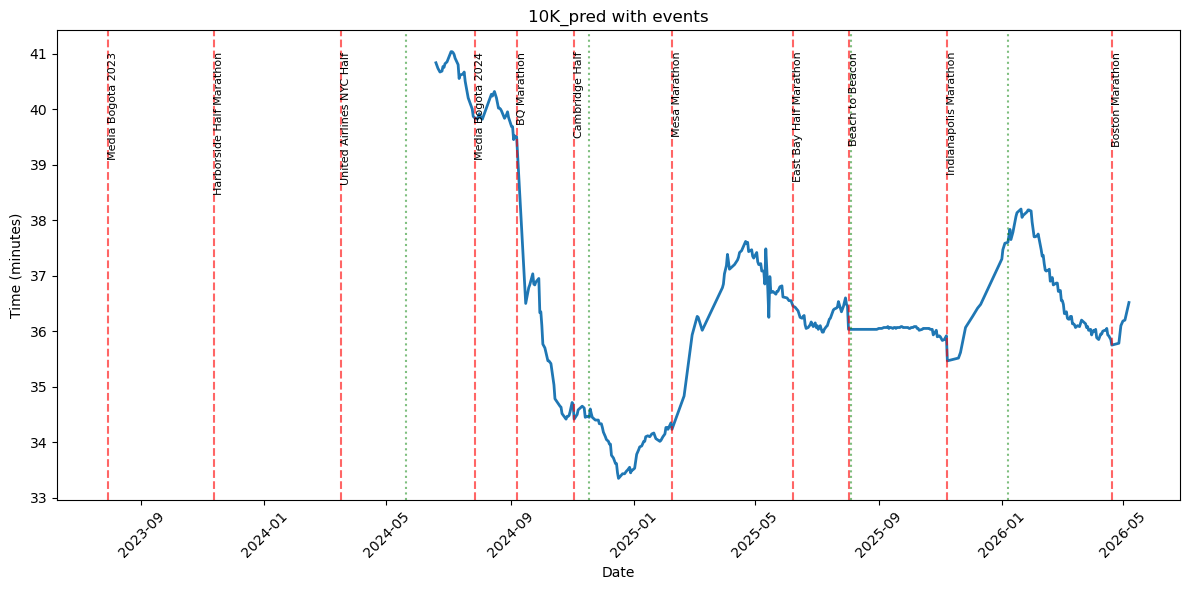

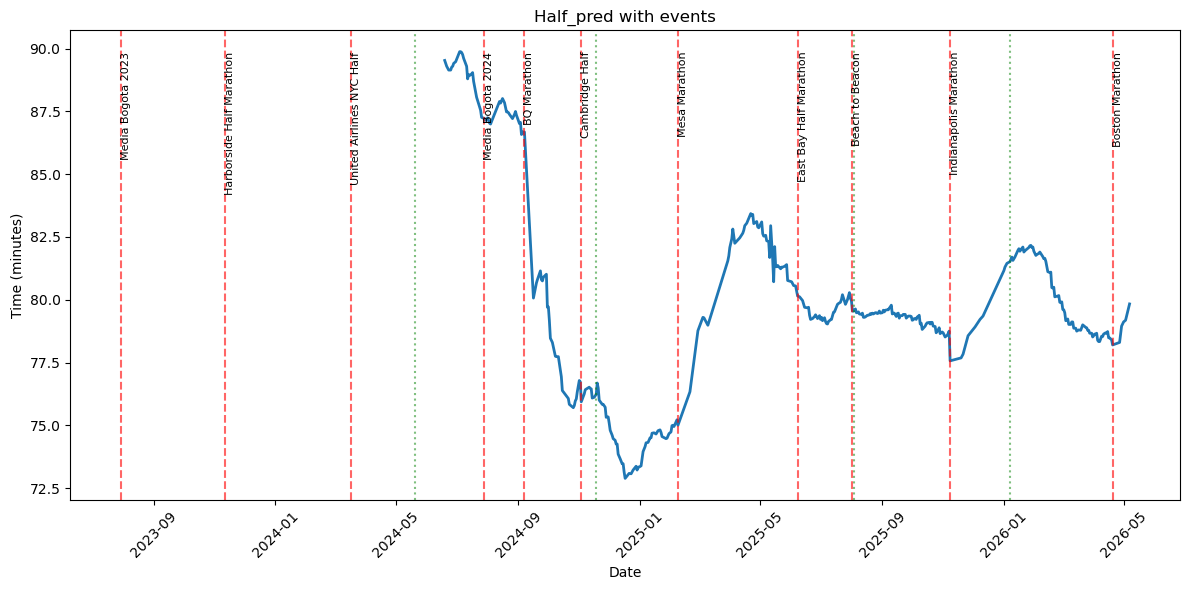

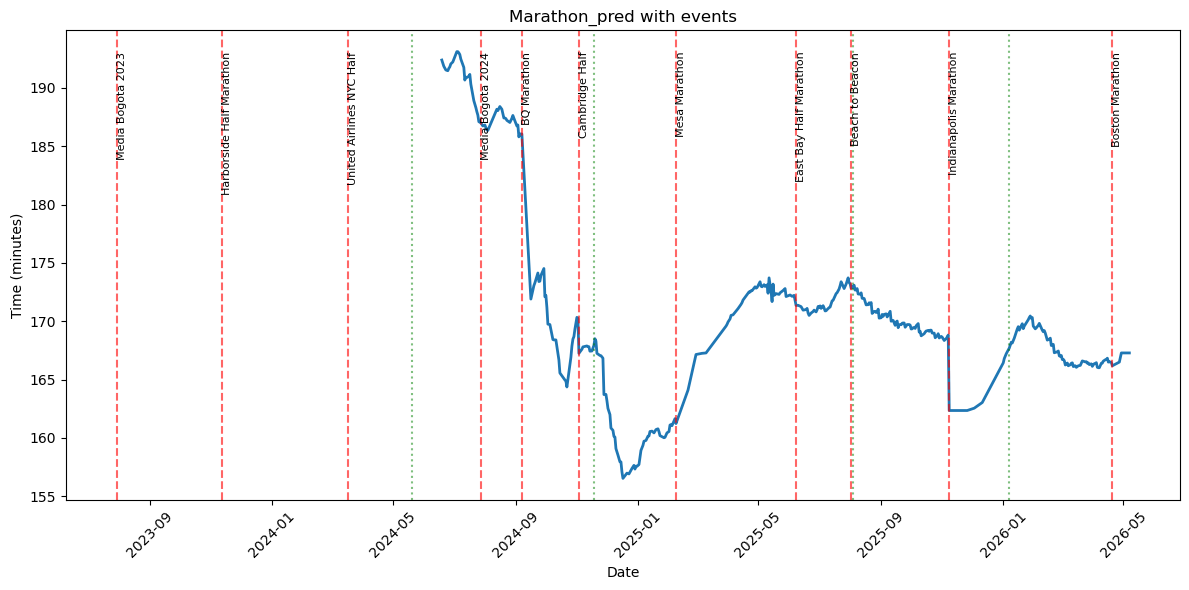

In [5]:
# Load the events table and convert the 'date' column to datetime
events_table = pd.read_csv(DATA_RAW_DIR / 'events_table.csv')
events_table['date'] = pd.to_datetime(events_table['date'])

# Select races
race_events = events_table[
    events_table["event_type"] == "race"
]

# Select training block starts ()
block_events = events_table[
    events_table["event_type"] == "training_block_start"
    ]

# Plot predictions with race and block start markers
for prediction in predictions_type:
    plot_line_with_events(
        events_table,
        daily_master_table,
        prediction,
        title=f'{prediction} with events'
    )

### Matching Predictions to Race Type

Because Garmin generates predictions for multiple race distances simultaneously (5K, 10K, Half Marathon, and Marathon), each race must be matched to its corresponding prediction type before evaluation.

For example:
- marathon races are evaluated against `Marathon_pred`,
- half marathons against `Half_pred`,
- and so on.

This creates a unified evaluation framework that allows Garmin prediction accuracy to be compared across race events.

When defining `prediction_date` I chose the prediction of the date prior to the race to prevent from any possible data leakage occuring as a result of the race being taken into account when the software makes it's race prediction.

In [6]:
# Prediction date = day before race
race_events["prediction_date"] = race_events["date"] - pd.Timedelta(days=1)

# Select prediction columns
prediction_cols = [
    "date",
    "5K_pred",
    "10K_pred",
    "Half_pred",
    "Marathon_pred"
]

daily_sorted = daily_master_table.sort_values("date")
race_sorted = race_events.sort_values("prediction_date")

race_prediction_eval_df = merge_dataframes_asof(
    left_df=race_sorted,
    right_df=daily_sorted[prediction_cols],
    left_on="prediction_date",
    right_on="date",
    direction="backward"
)

race_prediction_eval_df = race_prediction_eval_df.rename(
    columns={"date_x": "race_date", "date_y": "prediction_date_matched"}
)


/var/folders/5p/042l2mfn5lg_ltr5w11xxs9h0000gn/T/ipykernel_14101/934245790.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  race_events["prediction_date"] = race_events["date"] - pd.Timedelta(days=1)


### Prediction Error
Now I will compute prediction error of the races by:
    `prediction_error` = `relevant_pred` - `official_time_min`

This metric will allow me to evaluate statistical trends of the predictions.

In [7]:
# Get the relevant prediction for each race
race_prediction_eval_df["relevant_prediction"] = (
    race_prediction_eval_df.apply(
        get_relevant_prediction,
        axis=1
    )
)

# Compute prediction error
race_prediction_eval_df["prediction_error"] = (
    race_prediction_eval_df["relevant_prediction"]
    - race_prediction_eval_df["official_time_min"]
)

# Display statistics about prediction error
race_prediction_eval_df.groupby("race_type")[
    "prediction_error"
].agg(["mean", "std", "count"])

,mean,std,count
race_type,,,
10k,-0.117000,NaN,1
half,-1.855667,1.683857,3
marathon,-0.573992,6.295077,4


The statistical features of prediction error by `race_type` is incredibly informative.
- I run more longer distance races (half and full marathons)
- As the distance of the race increases, the standard deviation of the error also increases.
- On average it appears that Garmin's predictions are usually faster than my actual times
    - This is more apparent for the half marathon distance. 


### Official Time vs. Garmin Prediction
The following visualization illustrates where my official race times compare to Garmin's prediction. Each race is represented as a circle. If the circle lies above the dotted line (perfect prediction) then my time was faster than the prediction, conversely, if the circle lies below the dotted line my official time was slower. 

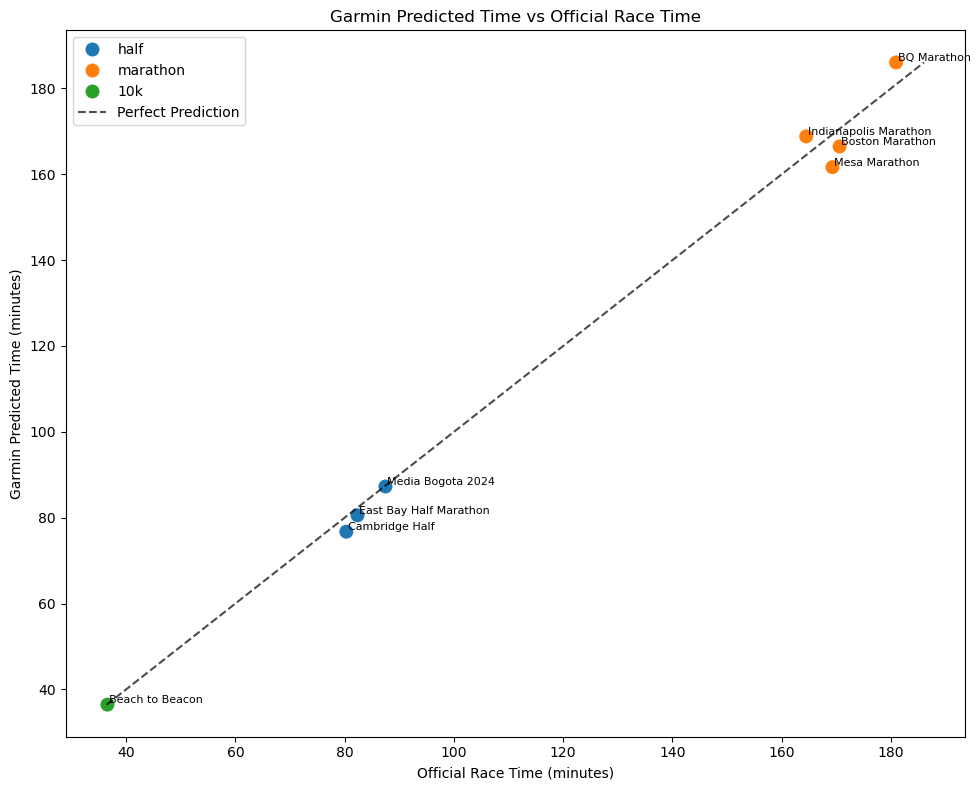

In [8]:
# Plot official time vs predicted time
plt.figure(figsize=(10, 8))

# Scatter plot
sns.scatterplot(
    data=race_prediction_eval_df,
    x="official_time_min",
    y="relevant_prediction",
    hue="race_type",
    s=120
)

# Perfect prediction reference line
min_val = min(
    race_prediction_eval_df["official_time_min"].min(),
    race_prediction_eval_df["relevant_prediction"].min()
)

max_val = max(
    race_prediction_eval_df["official_time_min"].max(),
    race_prediction_eval_df["relevant_prediction"].max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    color="black",
    alpha=0.7,
    label="Perfect Prediction"
)

# Annotate race names
for _, row in race_prediction_eval_df.iterrows():

    if pd.notna(row["relevant_prediction"]):

        plt.text(
            row["official_time_min"] + 0.3,
            row["relevant_prediction"] + 0.3,
            row["label"],
            fontsize=8
        )

plt.title("Garmin Predicted Time vs Official Race Time")
plt.xlabel("Official Race Time (minutes)")
plt.ylabel("Garmin Predicted Time (minutes)")
plt.legend()
plt.tight_layout()
plt.show()

As can be observed above the official races I have ran can be placed into three categories:
- 10k
- Half Marathon
- Marathon
Unsurprisingly, most of the official races are marathons since that is the distance I've been training and racing for the past few years.

As mentioned previously, as the distance of the race increases, so does the standard deviation of the predictione error, which reflects that longer distances are harder to predict since there are more variables that come into play. 

In addition, I observe that my Garmin consistently predicts my half marathon time to be faster than what I actually run. On the other hand, marathon predictions are a bit more volatile with half of the samples being faster and the other half being slower. 

### Error by Race Type

I willl now proivde a visualization of error by race types, this once again shows how the marathon has the most volatile prediction error.

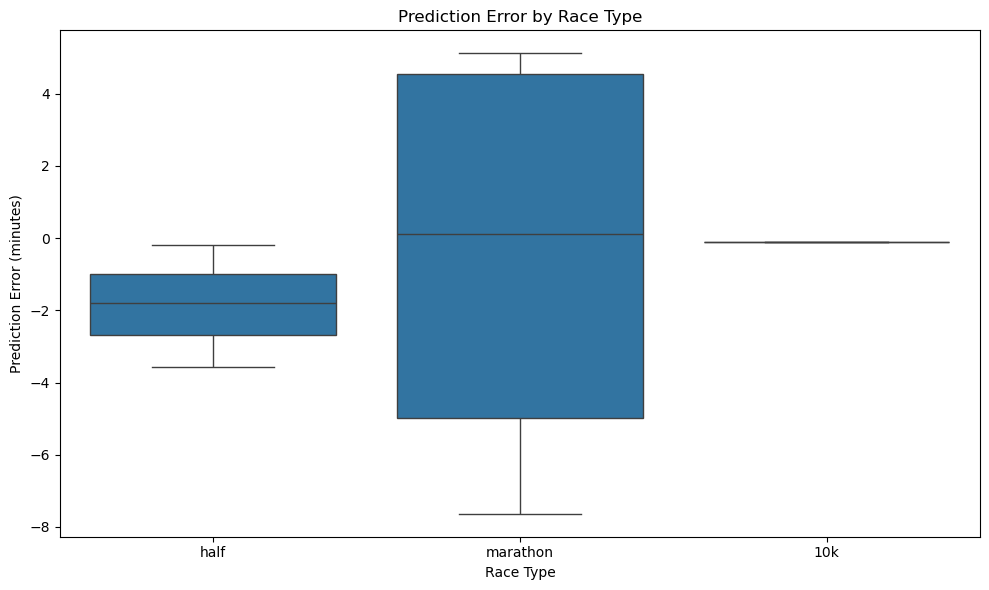

In [9]:
# Compute error by race type and plot boxplot of prediction error
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=race_prediction_eval_df, x="race_type", y="prediction_error")
plt.title("Prediction Error by Race Type")
plt.xlabel("Race Type")
plt.ylabel("Prediction Error (minutes)")
plt.tight_layout()
plt.show()

### Optimisim / Conservatism analysis
In order to compare the prediction of races I will categorize each prediction as being either optimistic or conservative. 
A race prediction is considered optimistic if `prediction_error` < 0, on the other hand, a race prediction is considered conservative if `prediction_error` > 0. There is no sample where `prediction_error` matches actual time, but this would be categorized as a neutral sample. 

In [10]:
# optimism/conservatism analysis
race_prediction_eval_df["error_category"] = race_prediction_eval_df["prediction_error"].apply(
    lambda x: "optimistic" if x < 0 else ("conservative" if x > 0 else "neutral"))

# Manually set inidianapolis marathon prediction date to be two days before the race, in order to address a bug where leakeage occured.
race_prediction_eval_df["prediction_date_matched"][9] = pd.to_datetime("2025-11-01")
race_prediction_eval_df["prediction_date"][9] = pd.to_datetime("2025-11-01")

/var/folders/5p/042l2mfn5lg_ltr5w11xxs9h0000gn/T/ipykernel_14101/411279466.py:6: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  race_prediction_eval_df["prediction_date_matched"][9] = pd.to_datetime("2025-11-01")
/var/folders/5p/042l2mfn5lg_l

### Volatility Analysis

In order to analyze the volatility in the data, I compute the rolling standard deviation of the predictions, in the 7, 15, and 30 days leading up to each race. These derived features will become essential for future analysis.

In [11]:
# Volatility analysis: compute rolling std of predictions in the 7, 15, and 30 days leading up to each race
time_windows = [7, 15, 30]

for time in time_windows:
    daily_master_table[f"rolling_std_{time}_5Kd"] = (
        daily_master_table["5K_pred"].rolling(window=time).std()
    )

    daily_master_table[f"rolling_std_{time}_10Kd"] = (
        daily_master_table["10K_pred"].rolling(window=time).std()
    )

    daily_master_table[f"rolling_std_{time}_Halfd"] = (
        daily_master_table["Half_pred"].rolling(window=time).std()
    )

    daily_master_table[f"rolling_std_{time}_Marathond"] = (
        daily_master_table["Marathon_pred"].rolling(window=time).std()
    )

# A lot of these dates are NaN because of the rolling window, but we can still merge these features into the race_prediction_eval_df for analysis
rolling_cols = [col for col in daily_master_table.columns if "rolling_std" in col]
daily_sorted = daily_master_table.sort_values("date")
race_prediction_eval_df = pd.merge_asof(
    race_prediction_eval_df,
    daily_sorted[["date"] + rolling_cols],
    left_on="prediction_date_matched",
    right_on="date",
    direction="backward"
)


I am interested in comparing the rolling standard deviation of the predictions between predictions categorized as optimistic and conservative. For this I will onlybe obeserving predictions for the half marathon and marathon distances since 5k and 10k predictions have a lot of missing values. 

### Marathon Blocks

For the remainder of this analysis, I will be focusing solely on my marathon races data for the following two reasons:
1. This is my main distance
2. There exists data for 4 main marathon blocks

I will create new dataframes for each marathon block which is roughly aroung 8-12 weeks of training. 


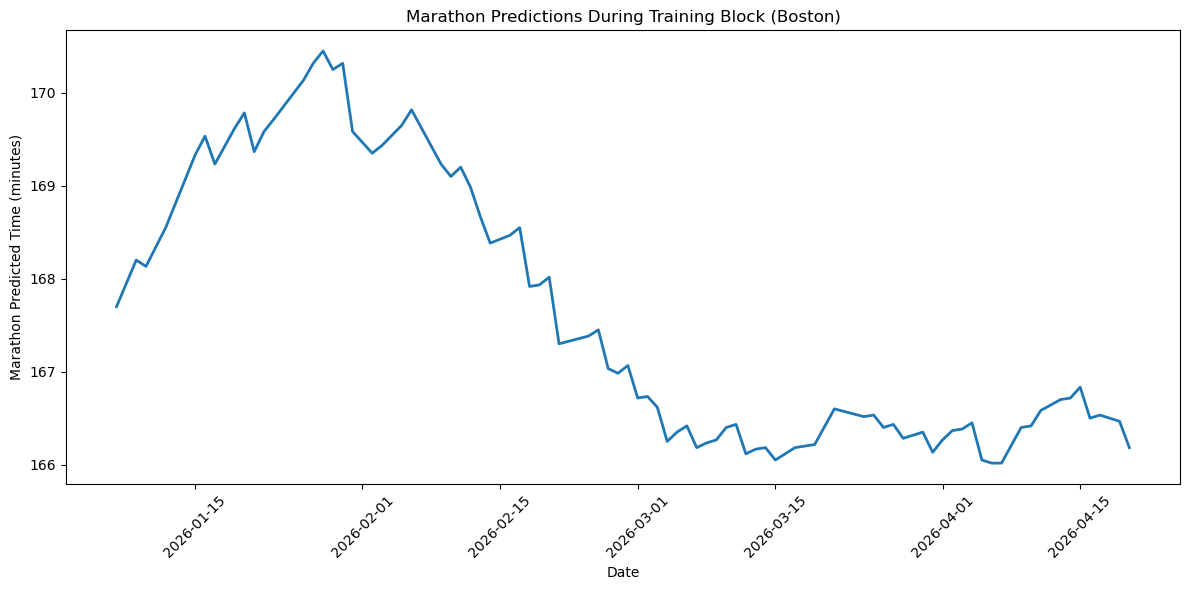

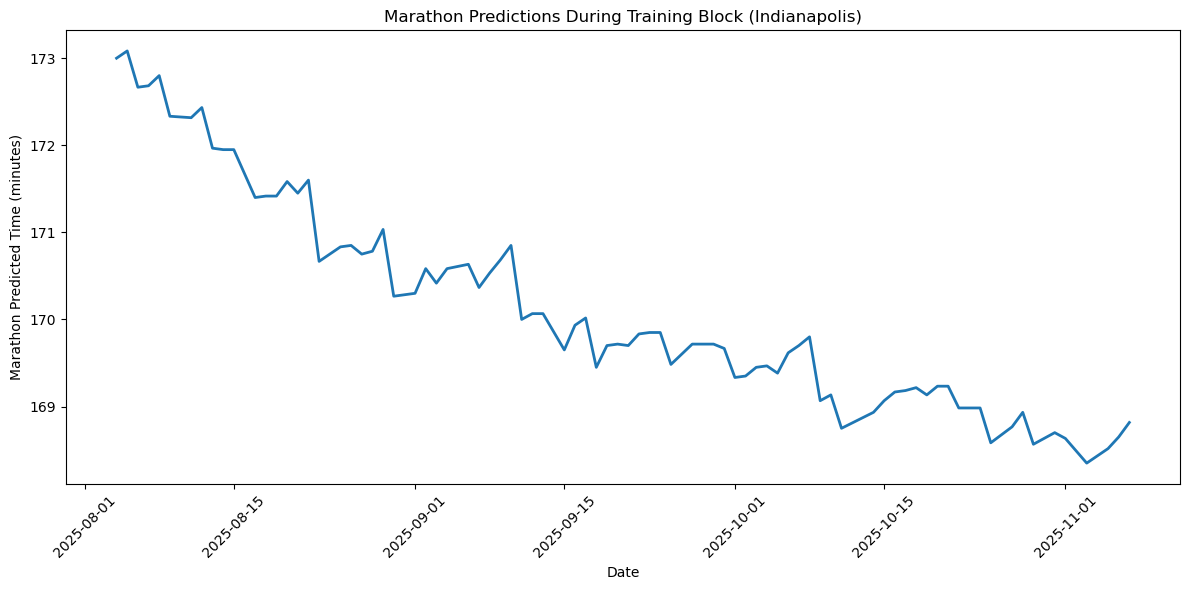

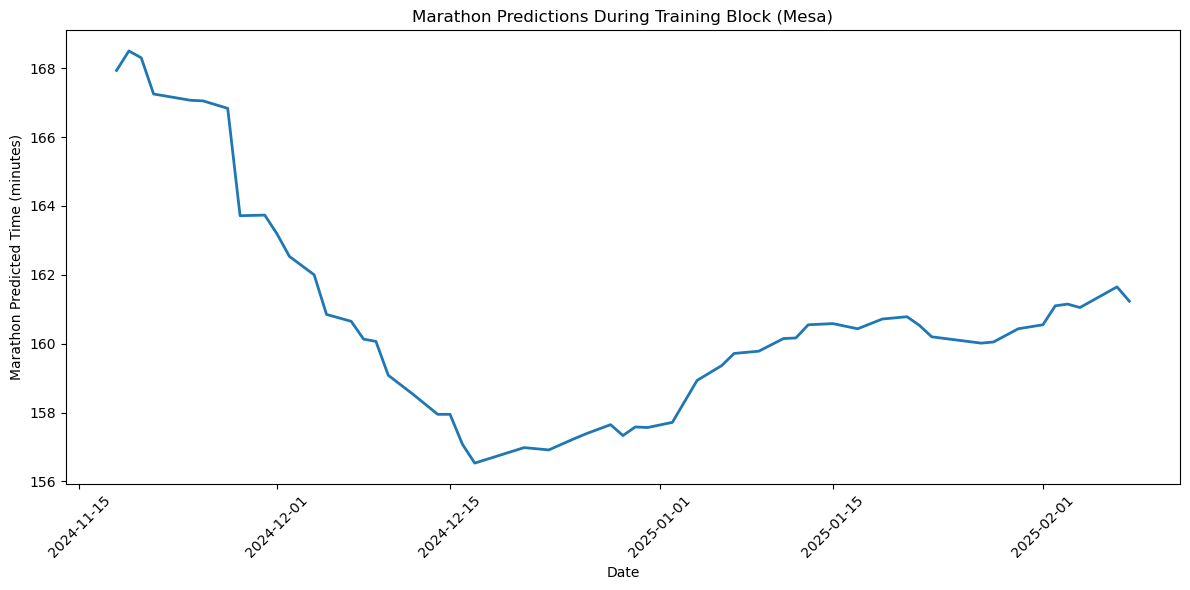

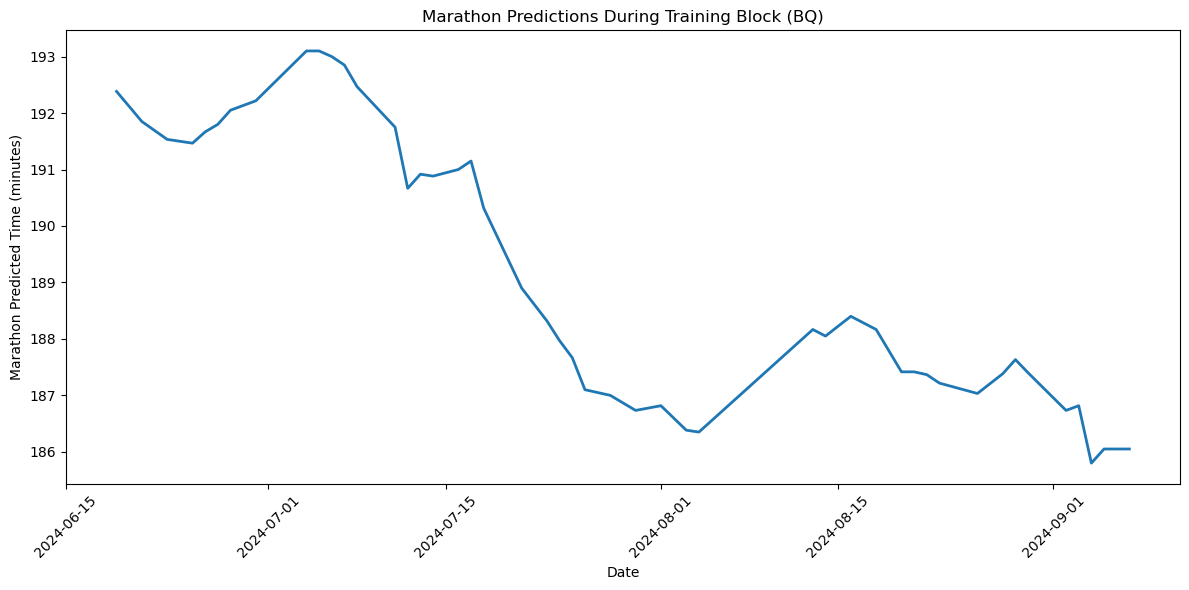

In [12]:
# There exist 4 marathon blocks in the events table
# Create a new dataframe for each marathon block using the dates in the table, manually select the dates
boston_block_daily = daily_master_table[
    (daily_master_table["date"] >= pd.to_datetime("2026-01-07")) &
    (daily_master_table["date"] <= pd.to_datetime("2026-04-20"))
]

indianapolis_block_daily = daily_master_table[
    (daily_master_table["date"] >= pd.to_datetime("8/4/25")) &
    (daily_master_table["date"] <= pd.to_datetime("11/7/25"))
]

mesa_block_daily = daily_master_table[
    (daily_master_table["date"] >= pd.to_datetime("11/18/24")) &
    (daily_master_table["date"] <= pd.to_datetime("2/8/25"))
]

bq_block_daily = daily_master_table[
    (daily_master_table["date"] >= pd.to_datetime("2024-06-19")) &
    (daily_master_table["date"] <= pd.to_datetime("9/7/24"))
]

marathon_blocks = {"Boston" : boston_block_daily, 
                   "Indianapolis" : indianapolis_block_daily, 
                   "Mesa" : mesa_block_daily, 
                   "BQ" : bq_block_daily}

# Plot marathon predictions over time for each marathon block
for block in marathon_blocks:
    plt.figure(figsize=(12, 6))
    sns.lineplot(
        data=marathon_blocks[block],
        x='date',
        y='Marathon_pred',
        linewidth=2
    )
    plt.title(f'Marathon Predictions During Training Block ({block})')
    plt.xlabel('Date')
    plt.ylabel('Marathon Predicted Time (minutes)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


The four plots above begin to reveal some very fascinating information about how Garmin's race prediction actually looks, mainly that the prediction evolution for each block looks very different.
- As expected the prediction time from the beginning of the block to the end decreases for all four blocks.
- I observe hump structures in all plots, however these all vary in size and in when they occur during the block.

In [13]:
# Add information from the race_prediction_eval_df into the marathon block dataframes for further analysis
boston_block_daily = pd.merge_asof(
    boston_block_daily.sort_values("date"),
    race_prediction_eval_df.sort_values("date"),
    on="date",
    direction="backward"
)
indianapolis_block_daily = pd.merge_asof(
    indianapolis_block_daily.sort_values("date"),
    race_prediction_eval_df.sort_values("date"),
    on="date",
    direction="backward"
)
mesa_block_daily = pd.merge_asof(
    mesa_block_daily.sort_values("date"),
    race_prediction_eval_df.sort_values("date"),
    on="date",
    direction="backward"
)
bq_block_daily = pd.merge_asof(
    bq_block_daily.sort_values("date"),
    race_prediction_eval_df.sort_values("date"),
    on="date",
    direction="backward"
)

# Clean up the marathon block dataframes by dropping columns that were duplicated during the merge and are not relevant
columns_to_drop = [
    "5K_pred_y",
    "10K_pred_y",
    "Half_pred_y",
    "Marathon_pred_y",
    "rolling_std_7_5Kd_y",
    "rolling_std_15_5Kd_y",
    "rolling_std_30_5Kd_y",
    "rolling_std_7_10Kd_y",
    "rolling_std_15_10Kd_y",
    "rolling_std_30_10Kd_y",
    "rolling_std_7_Halfd_y",
    "rolling_std_15_Halfd_y",
    "rolling_std_30_Halfd_y",
    "rolling_std_7_Marathond_y",
    "rolling_std_15_Marathond_y",
    "rolling_std_30_Marathond_y",
    "5K_pred_x",
    "10K_pred_x",
    "Half_pred_x",
    "rolling_std_7_5Kd_x",
    "rolling_std_15_5Kd_x",
    "rolling_std_30_5Kd_x",
    "rolling_std_7_10Kd_x",
    "rolling_std_15_10Kd_x",
    "rolling_std_30_10Kd_x",
    "rolling_std_7_Halfd_x",
    "rolling_std_15_Halfd_x",
    "rolling_std_30_Halfd_x",
]

boston_block_daily = boston_block_daily.drop(columns=columns_to_drop)
indianapolis_block_daily = indianapolis_block_daily.drop(columns=columns_to_drop)
mesa_block_daily = mesa_block_daily.drop(columns=columns_to_drop)  
bq_block_daily = bq_block_daily.drop(columns=columns_to_drop)

# Create a column with proper race label in each marathon block dataframe
boston_block_daily["label"] = "Boston Marathon"
indianapolis_block_daily["label"] = "Indianapolis Marathon"
mesa_block_daily["label"] = "Mesa Marathon"
bq_block_daily["label"] = "BQ Marathon"

### Rolling Prediction Volatility Across Marathon Blocks

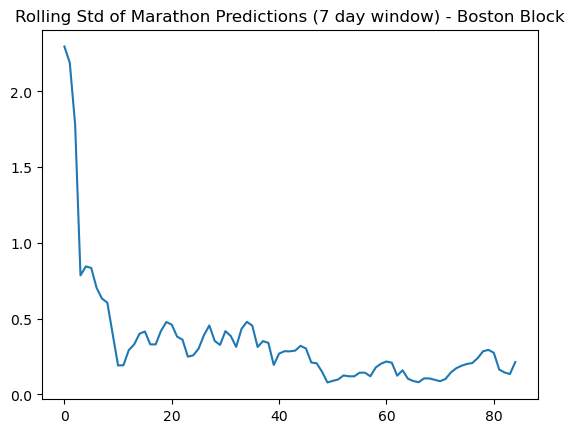

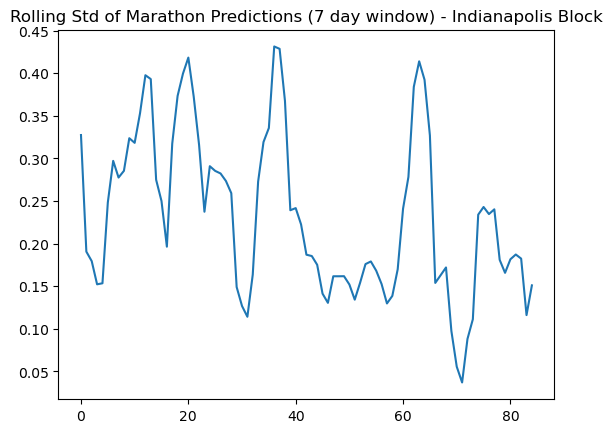

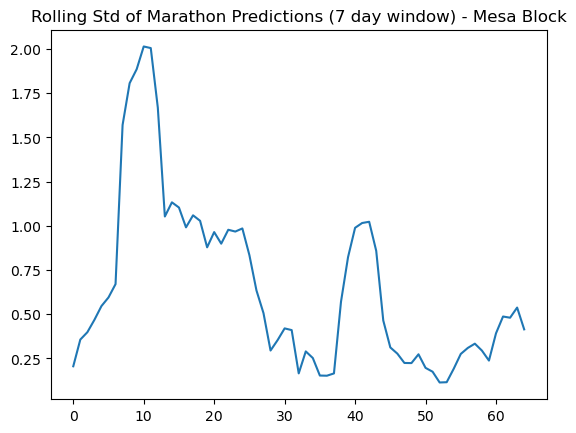

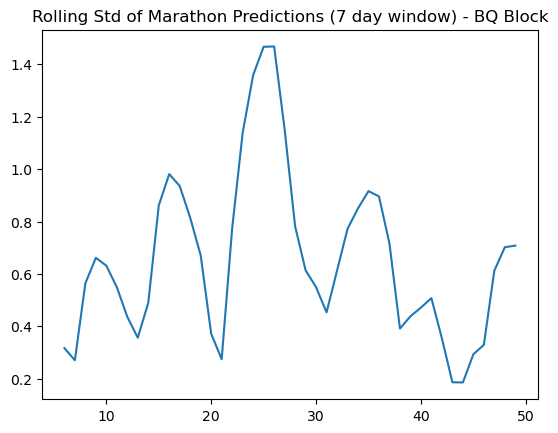

In [14]:
# Determine when predictions start to become more stable (less volatile) using the rolling std features in the marathon blocks
boston_block_daily["rolling_std_7_Marathond_x"].plot(title="Rolling Std of Marathon Predictions (7 day window) - Boston Block")
plt.show()

indianapolis_block_daily["rolling_std_7_Marathond_x"].plot(title="Rolling Std of Marathon Predictions (7 day window) - Indianapolis Block")
plt.show()

mesa_block_daily["rolling_std_7_Marathond_x"].plot(title="Rolling Std of Marathon Predictions (7 day window) - Mesa Block")
plt.show()

bq_block_daily["rolling_std_7_Marathond_x"].plot(title="Rolling Std of Marathon Predictions (7 day window) - BQ Block")
plt.show()

The rolling standard deviation plots reveal that Garmin marathon prediction behavior varies substantially across different training blocks. Rather than following a single consistent pattern, each block appears to exhibit its own distinct prediction dynamics.

Several observations stand out immediately:

- The Indianapolis Marathon block appears relatively stable throughout most of the training cycle, with consistently low rolling volatility. Interestingly, this block also resulted in the strongest marathon performance in the dataset.
  
- The Mesa Marathon block shows significantly higher volatility, including multiple abrupt spikes and large fluctuations in predicted marathon fitness. This same block also produced Garmin’s largest optimistic prediction error relative to the official race result.

- The Boston Marathon block demonstrates an initial adaptation period followed by a long phase of remarkably low volatility, suggesting that Garmin’s prediction system may have converged on a stable estimate of fitness late in the cycle.

- The BQ Marathon block displays repeated oscillatory behavior, with several cycles of increasing and decreasing volatility. This may indicate that Garmin repeatedly reevaluated fitness status throughout the build.

These results suggest that the *dynamics* of Garmin race predictions may be just as important as the final predicted value itself. In particular, prediction stability and volatility may provide insight into:
- training consistency,
- physiological adaptation,
- model confidence,
- or uncertainty in estimated marathon fitness.

At this stage, no definitive conclusions are being made. However, the differences between marathon blocks suggest that prediction volatility may be a meaningful signal worth investigating further.

In [15]:
boston_block_daily.to_parquet(
    DATA_DIR / 'boston_block_daily_v1.parquet',
    index=False
)
indianapolis_block_daily.to_parquet(
    DATA_DIR / 'indianapolis_block_daily_v1.parquet',
    index=False
)
mesa_block_daily.to_parquet(
    DATA_DIR / 'mesa_block_daily_v1.parquet',
    index=False
)
bq_block_daily.to_parquet(
    DATA_DIR / 'bq_block_daily_v1.parquet',
    index=False
)

### Block Summary Table

In [16]:
block_dict = {
    "BQ Marathon": bq_block_daily,
    "Mesa Marathon": mesa_block_daily,
    "Indianapolis Marathon": indianapolis_block_daily,
    "Boston Marathon": boston_block_daily
}

summary_rows = []

for block_name, df in block_dict.items():

    df = df.sort_values("date").reset_index(drop=True)

    # -----------------------------
    # Race row from evaluation df
    # -----------------------------
    race_row = race_prediction_eval_df[
        race_prediction_eval_df["label"].str.contains(
            block_name.split()[0],
            case=False,
            na=False
        )
    ].iloc[0]

    race_date = race_row["race_date"]
    actual_time = race_row["official_time_min"]
    final_prediction = race_row["relevant_prediction"]

    # -----------------------------
    # Prediction error
    # -----------------------------
    prediction_error = final_prediction - actual_time

    if prediction_error < -2:
        prediction_bias = "optimistic"
    elif prediction_error > 2:
        prediction_bias = "conservative"
    else:
        prediction_bias = "neutral"

    # -----------------------------
    # Volatility metrics
    # -----------------------------
    mean_volatility = df["rolling_std_7_Marathond_x"].mean()
    max_volatility = df["rolling_std_7_Marathond_x"].max()

    # -----------------------------
    # Stability logic
    # Define stable as:
    # within ±2 min of final prediction
    # -----------------------------
    tolerance = 2

    stable_mask = (
        (df["Marathon_pred_x"] - final_prediction)
        .abs()
        <= tolerance
    )

    stable_date = pd.NaT

    for i in range(len(df)):
        remaining = stable_mask.iloc[i:]

        if remaining.all():
            stable_date = df.iloc[i]["date"]
            break

    if pd.notnull(stable_date):
        days_stable_before_race = (
            pd.to_datetime(race_date) - stable_date
        ).days
    else:
        days_stable_before_race = np.nan

    # -----------------------------
    # Weekly mileage
    # -----------------------------
    daily_mileage = (
        df
        .groupby("date", as_index=False)["total_distance_miles"]
        .max()   # use max/first because duplicate dates repeat the same daily mileage
    )

    weekly_mileage = (
        daily_mileage
        .set_index("date")["total_distance_miles"]
        .resample("W-MON")   # optional: weeks ending Monday
        .sum()
    )

    peak_weekly_mileage = weekly_mileage.max()
    avg_weekly_mileage = weekly_mileage.mean()

    # -----------------------------
    # Last 14 day avg prediction
    # -----------------------------
    last_14_day_avg_prediction = (
        df.tail(14)["Marathon_pred_x"].mean()
    )

    # -----------------------------
    # Prediction drift
    # -----------------------------
    prediction_drift = (
        final_prediction
        - df["Marathon_pred_x"].iloc[0]
    )

    # -----------------------------
    # Avg training load
    # -----------------------------
    avg_training_load = (
        df["total_training_load"].mean()
    )

    # -----------------------------
    # Avg readiness
    # -----------------------------
    avg_readiness = (
        df["readiness_score_mean"].mean()
    )

    # -----------------------------
    # VO2 drift
    # -----------------------------
    vo2_drift = (
        df["vo2MaxValue"].iloc[-1]
        - df["vo2MaxValue"].iloc[0]
    )

    # -----------------------------
    # Avg HRV
    # -----------------------------
    avg_hrv = (
        df["hrv_weekly_avg_clean"].mean()
    )

    # -----------------------------
    # Append row
    # -----------------------------
    summary_rows.append({
        "block_name": block_name,
        "race_date": race_date,
        "actual_time": actual_time,
        "final_prediction": final_prediction,
        "prediction_error": prediction_error,
        "prediction_bias": prediction_bias,
        "mean_volatility": mean_volatility,
        "max_volatility": max_volatility,
        "stable_date": stable_date,
        "days_stable_before_race": days_stable_before_race,
        "peak_weekly_mileage": peak_weekly_mileage,
        "avg_weekly_mileage": avg_weekly_mileage,
        "last_14_day_avg_prediction": last_14_day_avg_prediction,
        "prediction_drift": prediction_drift,
        "avg_training_load": avg_training_load,
        "avg_readiness": avg_readiness,
        "vo2_drift": vo2_drift,
        "avg_hrv": avg_hrv
    })

summary_table = pd.DataFrame(summary_rows)

table = tabulate(
    summary_table,
    headers="keys",
    tablefmt="pretty",
    showindex=False
)
print(table)

+-----------------------+---------------------+-------------+--------------------+--------------------+-----------------+--------------------+---------------------+---------------------+-------------------------+---------------------+--------------------+----------------------------+--------------------+--------------------+-------------------+-----------+--------------------+
|      block_name       |      race_date      | actual_time |  final_prediction  |  prediction_error  | prediction_bias |  mean_volatility   |   max_volatility    |     stable_date     | days_stable_before_race | peak_weekly_mileage | avg_weekly_mileage | last_14_day_avg_prediction |  prediction_drift  | avg_training_load  |   avg_readiness   | vo2_drift |      avg_hrv       |
+-----------------------+---------------------+-------------+--------------------+--------------------+-----------------+--------------------+---------------------+---------------------+-------------------------+---------------------+------

### Volatility vs Training Load

I am interested in exploring if aggresive training periods correspond to a more volatile Garmin prediction.

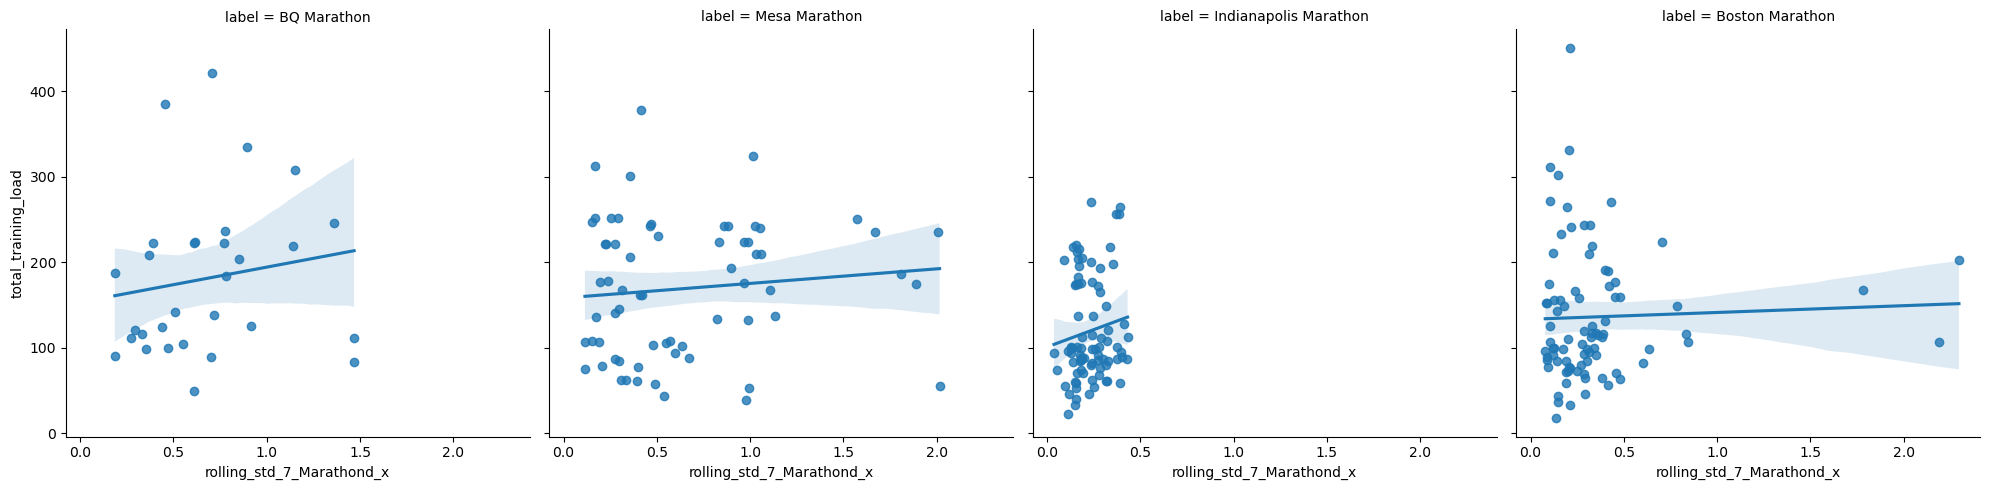

In [17]:
# Create a combined dataframe of all marathon blocks
all_marathons_df = pd.concat(block_dict.values(), ignore_index=True)

# filter out days with no training load to avoid skewing the analysis of volatility vs training load
all_marathons_df = all_marathons_df[all_marathons_df["total_training_load"] > 0]
sns.lmplot(
    data=all_marathons_df,
    x="rolling_std_7_Marathond_x",
    y="total_training_load",
    col="label"
)

<Axes: xlabel='rolling_std_7_Marathond_x', ylabel='total_training_load'>

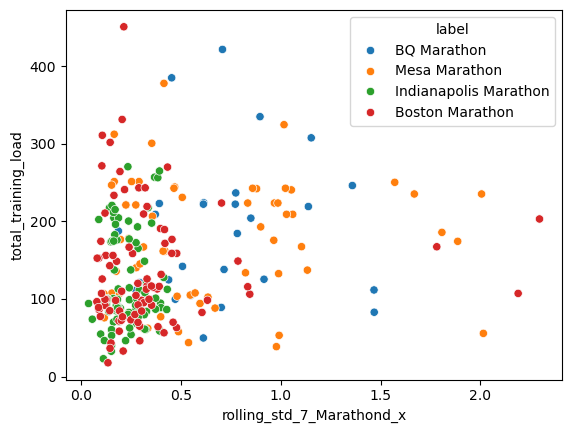

In [18]:
# Plot a scatter plot of prediction volatility vs training load, using data from marathon blocks
sns.scatterplot(
    data=all_marathons_df,
    x="rolling_std_7_Marathond_x",
    y="total_training_load",
    hue="label"
)

1. Indianapolis looks different as the cluster is concentrated at low volatility and relatively moderate treaining load. We can see points clustered thightly. This aligns with my earlier finding that indy was the most stable block.

2. Mesa looks chaotic with far right volatility and spread across huge training load ranges. This supports my idea that aggresive load blocks may destabilize predictions. After all Mesa had highest optimism error, larger drifts and high mileage.

3. Boston has mostly low-to-mid volatility but several VERY high training-load days at low volatilty. This may be interpreted as high load alone may not produce instability, but instead a combination of consistency, adaptation or load structure. 

4. BQ appears more transisitional with more disperse points and inconsistent clustering. I believe this perfecty encapsulates a less mature marathon block which aligns with it being my first marathon block ever.

In [19]:
# Add correlation values for each marathon block
marathon_blocks = ["BQ Marathon", "Mesa Marathon", "Indianapolis Marathon", "Boston Marathon"]
for block in marathon_blocks:
    corr = block_dict[block][["rolling_std_7_Marathond_x", "total_training_load"]].corr().iloc[0, 1]
    print(f"Correlation between prediction volatility and training load for {block}: {corr:.2f}")

Correlation between prediction volatility and training load for BQ Marathon: 0.17
Correlation between prediction volatility and training load for Mesa Marathon: 0.11
Correlation between prediction volatility and training load for Indianapolis Marathon: 0.08
Correlation between prediction volatility and training load for Boston Marathon: 0.04


The relationship between training load and prediction volatilty does not appear strictly linear across marathon blocks. While some high-load periods corrseponded with elevated volatility (specifically during the Mesa block) other blocks such as the Boston block maintaned relatively stable predictions despite sustained high training loads.

This suggests that Garmin prediction volatility may depend more heavily on broader block structure, consistency, or adaptation state rather than absolute training load alone.

### Daily Acute Chronic Workload Ratio vs Volatility

<Axes: xlabel='rolling_std_7_Marathond_x', ylabel='dailyAcuteChronicWorkloadRatio'>

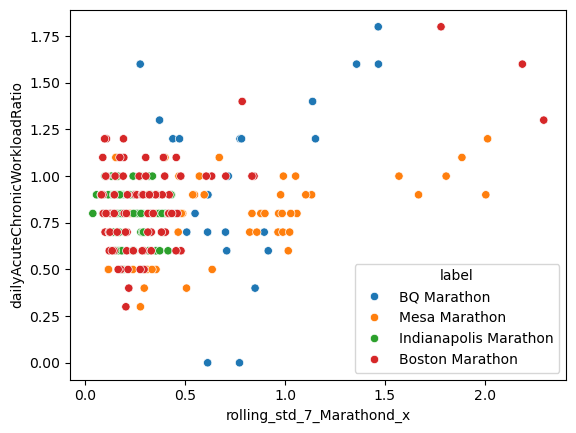

In [20]:
# Plot a scatter plot of prediction volatility vs daily acute chronic workload ratio, using data from marathon blocks
sns.scatterplot(
    data=all_marathons_df,
    x="rolling_std_7_Marathond_x",
    y="dailyAcuteChronicWorkloadRatio",
    hue="label"
)

- High volatility rarely occurs at very low ACWR. 
- Indianapolis is again the tightest cluster.
- There may be a theshold effect, it looks like volatility appears to expand once ACWR gets elevated

<Axes: xlabel='rolling_std_7_Marathond_x', ylabel='dailyAcuteChronicWorkloadRatio'>

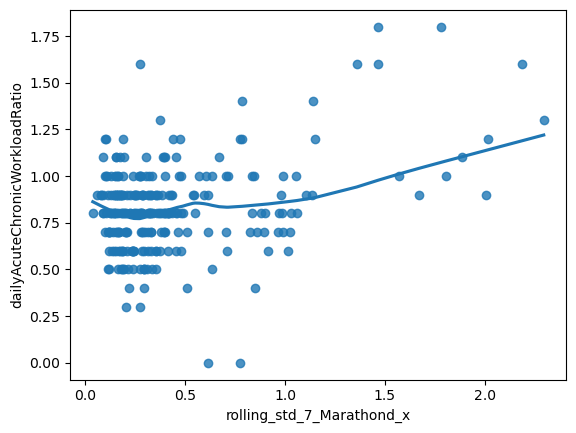

In [21]:
sns.regplot(
    data=all_marathons_df,
    x="rolling_std_7_Marathond_x",
    y="dailyAcuteChronicWorkloadRatio",
    lowess=True
)

### Training Readiness vs Volatility

<Axes: xlabel='rolling_std_7_Marathond_x', ylabel='readiness_score_mean'>

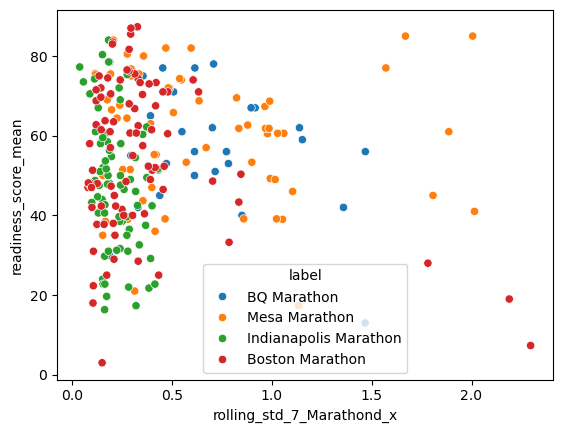

In [22]:
# Plot a scatter plot of prediction volatility vs training load, using data from marathon blocks
sns.scatterplot(
    data=all_marathons_df,
    x="rolling_std_7_Marathond_x",
    y="readiness_score_mean",
    hue="label"
)

<Axes: xlabel='rolling_std_7_Marathond_x', ylabel='readiness_score_mean'>

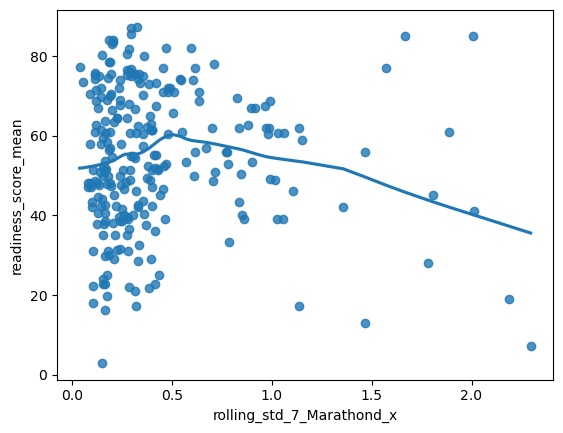

In [23]:
sns.regplot(
    data=all_marathons_df,
    x="rolling_std_7_Marathond_x",
    y="readiness_score_mean",
    lowess=True
)

Additional exploratory analysis was performed to investigate whether periods of elevated prediction volatility corresponded with broader physiological or training-state metrics.

The relationship between volatility and readiness score appeared relatively weak overall, suggesting that Garmin prediction stability is not determined by readiness alone. However, the highest volatility observations frequently coincided with lower readiness states, potentially indicating that unstable prediction periods emerge more often during physiologically stressed or inconsistent phases of training.

Similarly, elevated acute-to-chronic workload ratios occasionally aligned with increased volatility, although the relationship remained inconsistent across marathon blocks. These findings suggest that prediction volatility may depend more heavily on broader training dynamics and block structure than on any single physiological metric in isolation.

### Prediction Stabilization During Marathon Blocks

To better understand how Garmin marathon predictions evolved throughout training cycles, a stabilization framework was introduced. A prediction was considered “stable” once all remaining marathon predictions stayed within ±2 minutes of the final pre-race prediction.



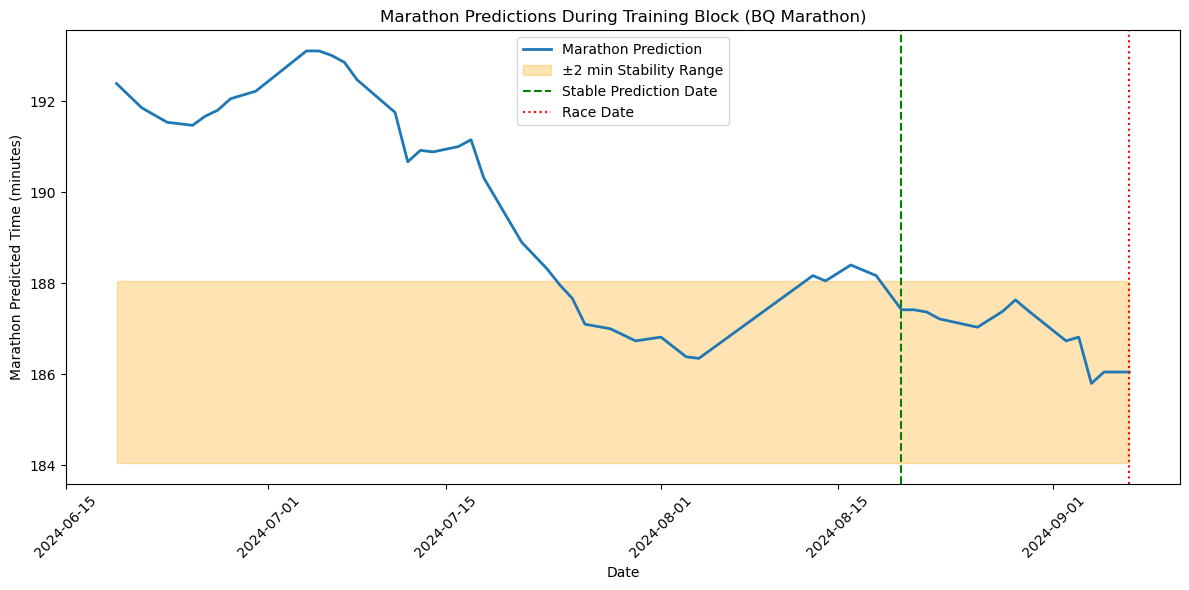

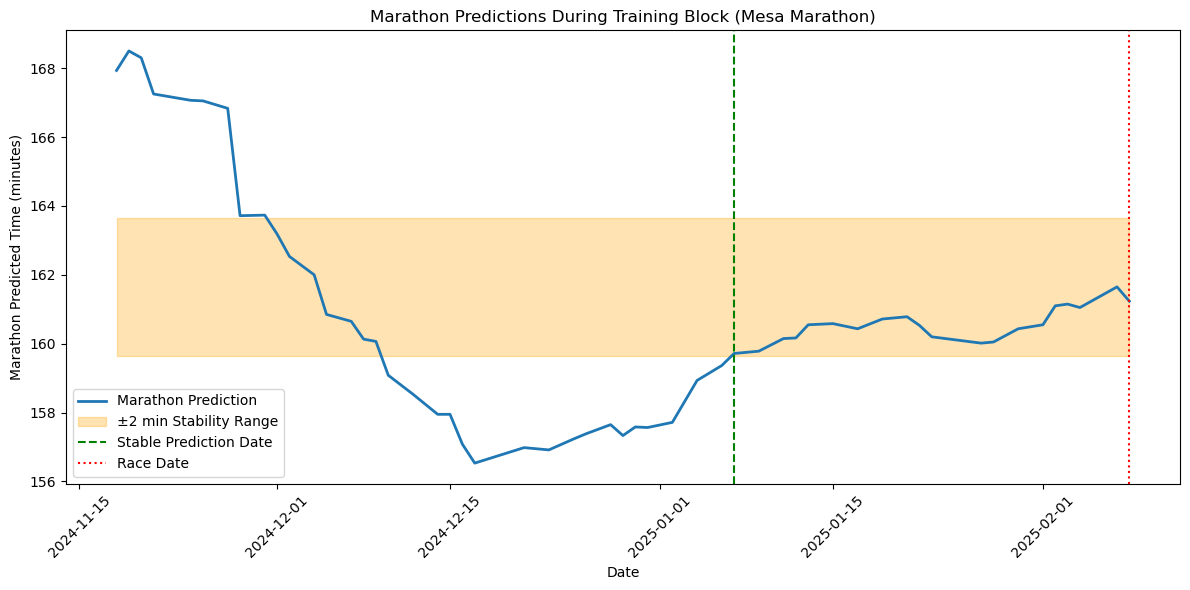

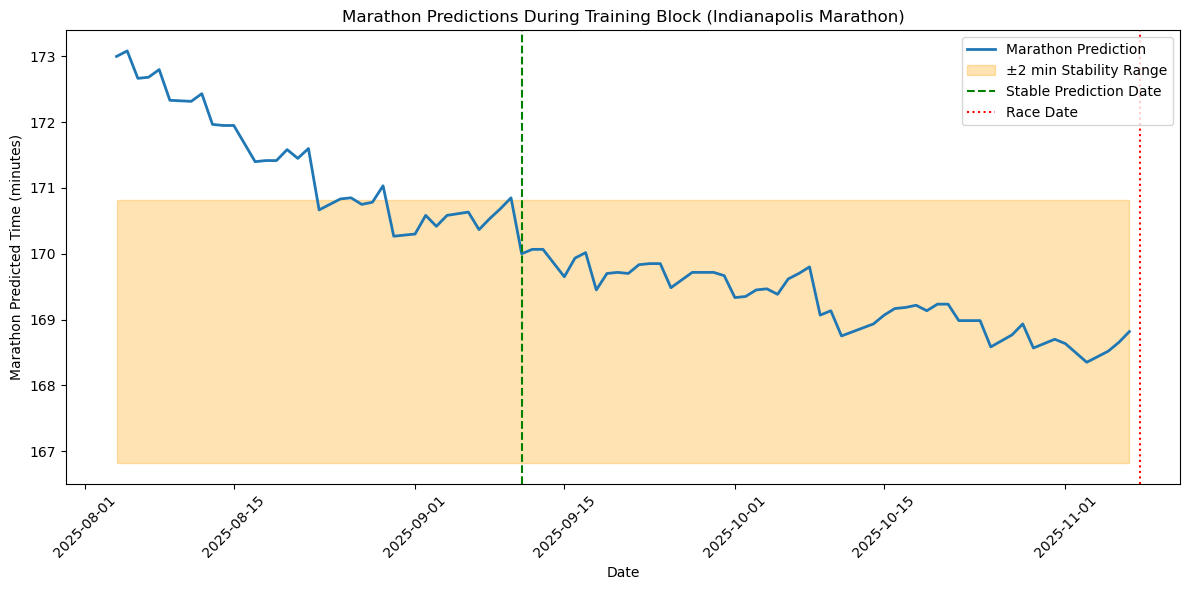

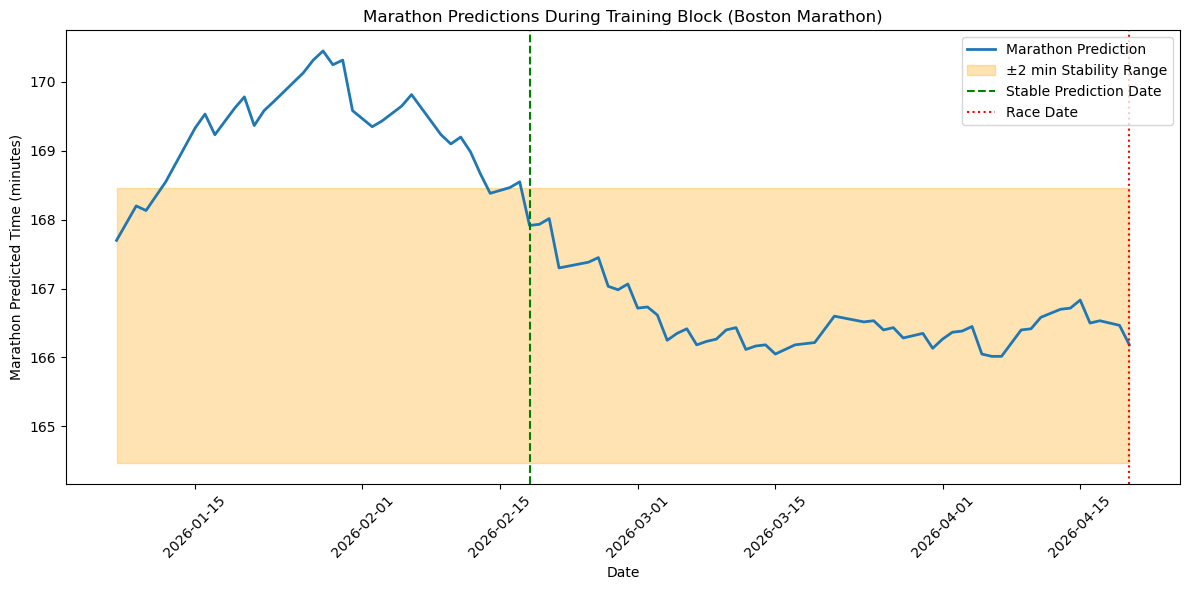

In [24]:
# For each block plot marathon prediction line and a shaded +/- 2 min area around the final prediction to visualize stability and a vertical line at stable date
for block_name, df in block_dict.items():

    final_prediction = (
        summary_table.loc[
            summary_table["block_name"] == block_name,
            "final_prediction"
        ].iloc[0]
    )

    race_date = (
        summary_table.loc[
            summary_table["block_name"] == block_name,
            "race_date"
        ].iloc[0]
    )

    plt.figure(figsize=(12, 6))
    sns.lineplot(
        data=df,
        x='date',
        y='Marathon_pred_x',
        linewidth=2,
        label='Marathon Prediction'
    )

    plt.fill_between(
        df["date"],
        final_prediction - 2,
        final_prediction + 2,
        color='orange',
        alpha=0.3,
        label='±2 min Stability Range'
    )

    # use stable_date from summary table for each block 
    stable_date = summary_table.loc[
        summary_table["block_name"] == block_name,
        "stable_date"
    ].iloc[0]
    
    plt.axvline(
        stable_date,
        color='green',
        linestyle='--',
        label='Stable Prediction Date'
    )

    plt.axvline(
    race_date,
    color='red',
    linestyle=':',
    label='Race Date'
)

    plt.title(f'Marathon Predictions During Training Block ({block_name})')
    plt.xlabel('Date')
    plt.ylabel('Marathon Predicted Time (minutes)')
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

The resulting visualizations revealed substantial differences between marathon blocks. Some blocks, such as Indianapolis and Boston, stabilized remarkably early and remained highly consistent throughout the latter portion of training. Other blocks, such as BQ Marathon, exhibited later stabilization and greater prediction oscillation near race day.

These findings suggest that prediction stabilization behavior may itself contain meaningful information about marathon block consistency, adaptation, or physiological uncertainty beyond the final predicted race time alone.

## Preliminary Findings

Several meaningful patterns emerged throughout the analysis of my Garmin race prediction dynamics across marathon training blocks.

### Prediction Dynamics Vary Substantially Between Marathon Blocks

My Garmin marathon predictions did not evolve uniformly across training cycles. Some blocks displayed relatively stable prediction behavior, while others showed significant short-term volatility and larger swings in projected marathon fitness.

The Indianapolis Marathon block exhibited the lowest prediction volatility by a substantial margin. Predictions remained highly stable throughout the latter portion of the block and converged early toward the final pre-race estimate. This block also corresponded with the strongest marathon performance and highest sustained training volume in the dataset.

In contrast, the Mesa Marathon block displayed significantly higher volatility and Garmin’s largest optimistic prediction error. Predictions fluctuated more aggressively throughout the training cycle, despite relatively strong training load and mileage metrics. This suggests that Garmin’s prediction system may become more reactive during aggressive or rapidly changing marathon blocks.

### Prediction Stabilization Appears Meaningful

A key observation throughout the analysis was that marathon predictions often stabilized weeks before race day. Some blocks converged toward a narrow prediction range more than one month before the race itself.

This stabilization behavior may contain more useful information than the final race prediction alone. Stable prediction periods could potentially reflect consistent training adaptation, lower physiological uncertainty, or more mature marathon-specific fitness.

There is early stabilization differences among all four blocks and it appears as though converegce behavior is also block-specific. For the most part is looks like Indy and Boston are rather stable and BQ has later convergence.

### Relationship between Volatility and Physiological Features Appears Weak
From the analysis on my data I observed no strong relationship between volatility of predictions and traning readiness, AWCR, or training loads.

However, there is interesting structures within each marathon block which supports the nuanced nature of endurance training. 

### Garmin Prediction Bias Was Not Uniform

Garmin predictions alternated between optimistic and conservative behavior across races. Some marathon blocks produced overly aggressive predictions, while others underestimated final race performance.

This inconsistency suggests that prediction error may depend more heavily on the structure and dynamics of the training block itself rather than a simple systematic model bias.

### Race-Day Prediction Leakage Was Observed

One of the most important methodological findings was the discovery of race-day prediction leakage. In several cases, Garmin marathon predictions changed dramatically on the day of the race itself, producing artificial spikes in rolling volatility metrics.

This suggests that Garmin predictions may partially incorporate race-day activity data before final synchronization or model updates occur. To avoid leakage effects, subsequent volatility analysis was restricted to pre-race prediction data only.

### Real-World Wearable Data Required Significant Cleaning

The analysis also revealed several challenges commonly associated with wearable telemetry datasets, including:

* duplicate daily readiness snapshots,
* invalid HRV placeholder values,
* race-day leakage effects,
* and inconsistencies between prediction timestamps and race outcomes.

These issues required substantial preprocessing and methodological adjustments before meaningful longitudinal analysis could be performed.


## Limitations
The following limitations must be considered when interpreting the results of my analysis:

### Single-Athlete Dataset
This project is based entirely (as of today) on data collected from my personal marathon training cycles. As a result, the finidings should be interpreted as exploratory observations rather than generalizable conclusions about Garmin's prediction systems or endurance performance modeling. 

### Limited Number of Marathon Races
Although data spans multiple years of training, the number of fully documented marathon races is low (4). This limits the statistical power of block comparisons and makes it very challenging to draw definite conclusions about relationships between volatility, training structure, and race outcomes. 

### Wearable Data Quality Issues
The Garmin export data required substantiial preprocessing. These issues introduce a slight level of uncertainity into some of my derived metrics and required many manual cleaning decisions throughout the analysis pipeline.

### Device and Historial Data Inconsistency
Earlier portions of the dataset were collected using older Garmin devices with fewer physiological metrics and potentially lower sensor quality. Some early race predictions and physiological estimates may therefore be less reliable than later observations.  

## Conclusion
This early stage of the project explored the longitudional behavior of Garmin race predictions using multi-year training, recovery, and physiological telemetry data extracted from Garmin Connect exports.

While my analysis is still rather exploratory and is limited to only my data, several meaningful patterns emerged. Marathon prediction behavior appeared to vary significantly across training blocks, with some cycles showing stable and early-converging predictions while others displayed high volatility and larger prediction errors. This all suggests that prediction stability itself may contain meaningful implicit information about training adaptadion and race readiness beyond the final predicted race time alone. 

More broadly, this stage of the project demonstrates the potential value of combining wearable technology, longitudional training data, and custom analytical workflows to investigate endurance performance dynamics over time. It also highlights many of the challenges associated with real-world physiological datasets, such as inconsistent device behavior.

Future work could include:
* incorporating more athletes
* exploring relationships between volatility and physiological metrics such as HRV or taining load
* developing predictive models for race outcomes or readiness
* and building interactive dashboards for longitudional performance exploration.

This project has evolved from a personal data exploration into a broader investigation of how wearable systems work throughout marathon training cycles.